<a href="https://colab.research.google.com/github/nest-or-star/hfst_valteh/blob/main/MD1_HFST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Galīgo automātu lietojums morfoloģijā | Finite state automata for morphology

**Nestors Starostins, ns23044**

Helsinki Finite State Transdusers (HFST)

Skat. arī.: https://github.com/hfst/compmorph-course/tree/v1.0

In [111]:
!pip install hfst==3.16.0.1
# !pip install hfst_dev
# !pip install graphviz

In [112]:
import hfst
# import hfst_dev
# import graphviz
from IPython.display import Image

In [113]:
# help(hfst)
# help(hfst.compile_lexc_file)
# help(hfst.compile_twolc_file)

Tiek aprakstīta lietvārdu locīšana krievu valodā.

Lietvārdus loka pēc skaitļa (viensk., daudzsk.) un 6 locījumiem (Nominatīvs, Ģenitīvs, Datīvs, Akuzatīvs, Instrumentālis, Prepozicionāls, atdarinot angļu nosaukumus), turklāt ir 3 deklinācijas, 3 dzimtes un dažādas smalkas variācijas, kas atkarīgas no galotnes un vārda nozīmes.

Šeit ir iekļauti I deklinācijas sieviešu dzimtes animate un inanimate vārdi un II deklinācijas vīriešu dzimtes animate un neitrālās dzimtes inanimate vārdi.

Vārdus pierakstu ar ISO 9 standartā aprakstīto 1:1 atbilstību starp kirilicu un latīņu alfabētu.

In [114]:
# Leksikona augšuplāde no faila
!wget https://raw.githubusercontent.com/nest-or-star/hfst_valteh/refs/heads/main/Russian.lexc

--2026-03-26 21:52:33--  https://raw.githubusercontent.com/nest-or-star/hfst_valteh/refs/heads/main/Russian.lexc
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1374 (1.3K) [text/plain]
Saving to: ‘Russian.lexc.1’

Russian.lexc.1      100%[===================>]   1.34K  --.-KB/s    in 0s      

2026-03-26 21:52:33 (60.8 MB/s) - ‘Russian.lexc.1’ saved [1374/1374]



In [115]:
from hfst import compile_lexc_file
generator = hfst.compile_lexc_file('Russian.lexc')
print(generator.lookup('rek+N+Sg+Dat'))
# print (generator)


(('rek^e@_EPSILON_SYMBOL_@', 0.0),)


In [116]:
# Vizualizācija
# hfst2png(generator,'generator.png')
# Image('generator.png')

## Transdjūseri: divlīmeņu morfoloģija | Transducers: two-level morphology


In [117]:
# Sintēze | Synthesis
from hfst import HfstTransducer

analyzer = HfstTransducer(generator) # Create a copy

print(analyzer.lookup('rek+N+Sg+Nom'))

(('rek^a@_EPSILON_SYMBOL_@', 0.0),)


In [118]:
# Analīze | Analysis
analyzer.invert()
analyzer.minimize()

print(analyzer.lookup('rek^e'))

(('rek+N+Sg+Dat', 0.0), ('rek+N+Sg+Prep', 0.0))


In [119]:
# Salīdzināšana | Comparison
analyzer.invert()
analyzer.minimize()

print(analyzer.compare(generator))

True


In [120]:
from hfst import regex, HfstTransducer

### Iespraušana
Formās bez galotnes piedēklis -k- kļūst -ek-. Šajā gadījumā vārdā *devočka*.

In [121]:
# Insertion
InsertE = hfst.regex('[..] -> e || č _ k "^" Ø ')
print(InsertE.lookup("devočk^Ø"))

(('devoček^Ø', 0.0),)


### Aizstāšana
Vārdos, kas beidzas ar **'** vai **â**, tiek lietotas "mīkstākas" galotnes.

Vārdos, kuru sakne beidzas ar **k/g**, galotnes **y** vietā lieto **i**.

In [122]:
# Replacement
YSoftening = hfst.regex('y -> i || [k | g | j | \'] "^" _')
ASoftening = hfst.regex('a -> â || [j | \'] "^" _')
USoftening = hfst.regex('u -> û || [j | \'] "^" _')
OVSoftening = hfst.regex('o v -> e j || [j | \'] "^" _')
OMSoftening = hfst.regex('o -> e || [j | \'] "^" _ m')
OSoftening = hfst.regex('o -> ë || [j | \'] "^" _')


### Izņēmumi
*toska* (ilgas), *mâta* (piparmētra), *seno* (siens), *pivo* (alus) lieto tikai vienskaitli. Daudzskaitļa formas tiek pārveidotas par vienskaitli.

In [123]:
# Exceptions
NoPluralExc = hfst.regex('"+Pl" -> "+Sg" || [t o s k|m â t|s e n|p i v] "+N" _')
print(NoPluralExc.lookup("mât+N+Pl+Dat"))

(('mât+N+Sg+Dat', 0.0),)


### Dzēšana
Notīra nulles galotnes simbolu un **j/'** saknes beigās, kas norādīja uz galotnes mīkstināšanu.

In [124]:
# Deleting
JCleanup = hfst.regex('[j|\'] -> 0 || _ "^" [i|â|e|û|ë]')
OCleanup = hfst.regex('Ø -> 0')
Cleanup = hfst.regex('"^" -> 0')
print(JCleanup.lookup("olen'^i"))

(('olen@_EPSILON_SYMBOL_@^i', 0.0),)


## FST apvienošana | FST composition

In [125]:
from hfst import compose

# Sintēze | Generation
cascade = compose((NoPluralExc, generator, InsertE,
                   YSoftening, ASoftening, USoftening, OVSoftening, OMSoftening, OSoftening,
                   JCleanup, OCleanup, Cleanup))
print(cascade.lookup("tosk+N+Pl+Dat"))
print(cascade.lookup("tosk+N+Sg+Dat"))

(('tosk@_EPSILON_SYMBOL_@e@_EPSILON_SYMBOL_@', 0.0),)
(('tosk@_EPSILON_SYMBOL_@e@_EPSILON_SYMBOL_@', 0.0),)


In [126]:
# If you use the HFST library, you will need to remove the epsilon symbol.
cascade.remove_epsilons()
print(cascade.lookup("tosk+N+Sg+Dat")[0][0].replace("@_EPSILON_SYMBOL_@", ""))

toske


In [127]:
# Analīze | Analysis
inv = hfst.HfstTransducer(cascade)
inv.invert()
inv.convert(hfst.ImplementationType.HFST_OL_TYPE)
print(inv.lookup("mal'čikam"))
print(inv.lookup("devoček"))

(("mal'čik+N+Pl+Dat", 0.0),)
(('devočk+N+Pl+Acc', 0.0), ('devočk+N+Pl+Gen', 0.0))


## FST vizualizācija | FST visualization

In [128]:
import sys

def hfst2png(transducer, png_name):
    # Write the FST to a file using the att format
    f = open("a.att", "w", encoding="utf-8")
    transducer.minimize()
    transducer.write_att(f, False)

    # Convert the FST file to the dot format
    # dot format is used by graphviz library for graph visualization
    f = open("a.att", "r", encoding="utf-8")
    with open("graph.dot", "w", encoding="utf-8") as out_f:
        out_f.write('digraph G { rankdir="LR"\n')
        out_f.write('node [fontname="Tahoma",shape=circle,fontsize=14,fixedsize=true,fillcolor="grey",style=filled]\n')
        out_f.write('edge [fontname="FreeMono",fontsize=14]\n')
        for line in f.readlines():
            line = line.strip()
            row = line.split('\t')
            if len(row) >= 4:
                out_f.write('%s [label="%s"];\n' % (row[0], row[0]))
                out_f.write('%s -> %s [label="%s:%s"];\n' % (row[0], row[1], row[2], row[3]))
            elif len(row) == 1: # Final state
                out_f.write('%s [label="%s",shape=doublecircle];\n' % (row[0], row[0]))
        out_f.write('}')

    # Call graphviz dot function to generate a png file from dot file
    !dot -Tpng graph.dot > $png_name

In [129]:
# Call the transformation to png on the HFSTTransducer "cascade"
hfst2png(cascade,'image.png')

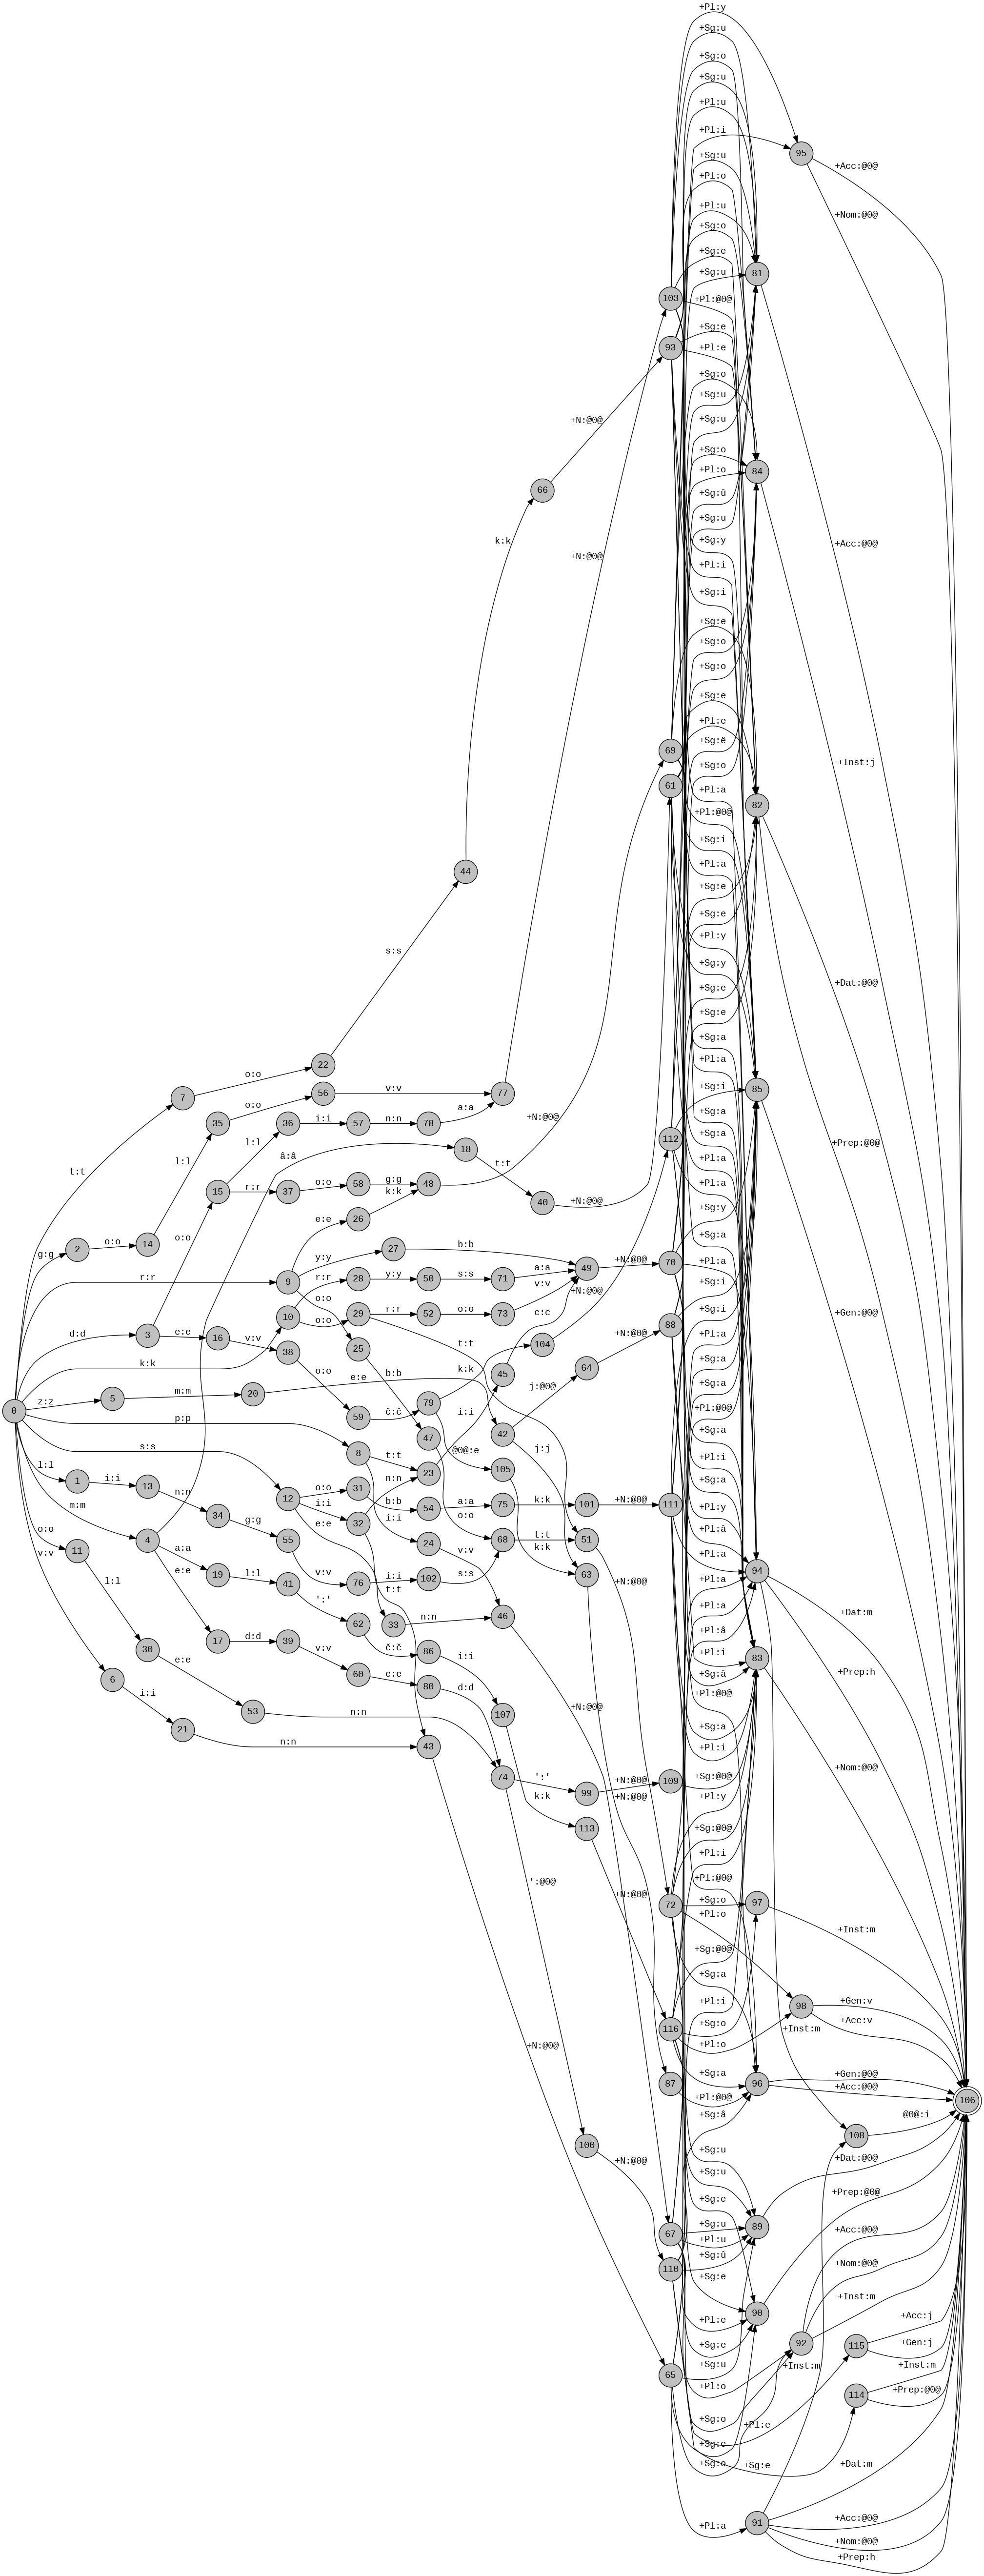

In [130]:
# Display image in notebook
# from IPython.display import Image
Image('image.png')

Izdrukāšana

In [131]:
nouns = ["sobak", "ryb", "ptic", "korov", "zmej", "devočk",
         "dorog", "rek", "golov", "tosk", "mât",
         "sen", "vin", "piv",
         "kot", "mal'čik", "lingvist", "olen'", "medved'"]
for noun in nouns:
    for number in ["Sg", "Pl"]:
        for form in ["Nom", "Gen", "Dat", "Acc", "Inst", "Prep"]:
            print(noun + "+N+" + number + "+" + form + " - " + cascade.lookup(noun + "+N+" + number + "+" + form)[0][0].replace("@_EPSILON_SYMBOL_@", ""))




sobak+N+Sg+Nom - sobaka
sobak+N+Sg+Gen - sobaki
sobak+N+Sg+Dat - sobake
sobak+N+Sg+Acc - sobaku
sobak+N+Sg+Inst - sobakoj
sobak+N+Sg+Prep - sobake
sobak+N+Pl+Nom - sobaki
sobak+N+Pl+Gen - sobak
sobak+N+Pl+Dat - sobakam
sobak+N+Pl+Acc - sobak
sobak+N+Pl+Inst - sobakami
sobak+N+Pl+Prep - sobakah
ryb+N+Sg+Nom - ryba
ryb+N+Sg+Gen - ryby
ryb+N+Sg+Dat - rybe
ryb+N+Sg+Acc - rybu
ryb+N+Sg+Inst - ryboj
ryb+N+Sg+Prep - rybe
ryb+N+Pl+Nom - ryby
ryb+N+Pl+Gen - ryb
ryb+N+Pl+Dat - rybam
ryb+N+Pl+Acc - ryb
ryb+N+Pl+Inst - rybami
ryb+N+Pl+Prep - rybah
ptic+N+Sg+Nom - ptica
ptic+N+Sg+Gen - pticy
ptic+N+Sg+Dat - ptice
ptic+N+Sg+Acc - pticu
ptic+N+Sg+Inst - pticoj
ptic+N+Sg+Prep - ptice
ptic+N+Pl+Nom - pticy
ptic+N+Pl+Gen - ptic
ptic+N+Pl+Dat - pticam
ptic+N+Pl+Acc - ptic
ptic+N+Pl+Inst - pticami
ptic+N+Pl+Prep - pticah
korov+N+Sg+Nom - korova
korov+N+Sg+Gen - korovy
korov+N+Sg+Dat - korove
korov+N+Sg+Acc - korovu
korov+N+Sg+Inst - korovoj
korov+N+Sg+Prep - korove
korov+N+Pl+Nom - korovy
korov+N+Pl+Gen -